In [ ]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

c:\Users\user\Desktop\younes\data_exploration\uv_project


In [282]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import calendar

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose

import tsfeatures as tsf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(30)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(10)

polars.config.Config

In [283]:
DATA_PATHS = [
    "data/smi_suiviexpedition (1).csv",
    "data/smi_suiviexpedition (2).csv",
    "data/smi_suiviexpedition (3).csv",
    "data/smi_suiviexpedition (4).csv",
    "data/smi_suiviexpedition (5).csv",
    "data/smi_suiviexpedition (6).csv",
    "data/smi_suiviexpedition (7).csv",
    "data/smi_suiviexpedition (8).csv",
    "data/smi_suiviexpedition (9).csv",
]

In [284]:
DELIVERED_STATUT = ["liv", "liv_ret"]

In [ ]:
import main

raw_dfs = []
for path in DATA_PATHS:
    input_file = main.get_input_file(path)

    raw_df = main.load_data(input_file)
    raw_df = raw_df.rename(main.COLUMN_MAPPING).filter(
        (pl.col("SITE_DERNIER_STATUT").is_in(main.our_locations))
    )
    raw_dfs.append(raw_df)

data = pl.concat(raw_dfs)

In [286]:
data = data.unique()

In [ ]:
data = data.filter(pl.date(2023, 1, 1) < pl.col("DATE_DERNIER_STATUT"))
data = data.sort("DATE_DERNIER_STATUT")
data = data.with_columns(
    pl.col("DERNIER_STATUT")
    .is_in(DELIVERED_STATUT)
    .cast(pl.Boolean)
    .alias("is_delivered")
)

In [288]:
print(data)

shape: (315_095, 10)
┌─────────────────────────────────┬─────────────────────────────────┬─────────────────────┬─────────────────────────────┬──────────────────────┬────────────────┬─────────────────────┬────────────────────────────────┬──────────────┬──────────────┐
│ CAB                             ┆ CLIENT                          ┆ SERVICES OPTIONNELS ┆ SITE EXPEDITEUR             ┆ RECEPTION(OK ou NOK) ┆ DERNIER STATUT ┆ DATE DERNIER STATUT ┆ SITE DERNIER STATUT            ┆ DESTINATION  ┆ is_delivered │
│ ---                             ┆ ---                             ┆ ---                 ┆ ---                         ┆ ---                  ┆ ---            ┆ ---                 ┆ ---                            ┆ ---          ┆ ---          │
│ str                             ┆ str                             ┆ str                 ┆ str                         ┆ str                  ┆ str            ┆ datetime[ms]        ┆ str                            ┆ str          ┆ bool  

In [ ]:
# print(data.group_by("SITE_DERNIER_STATUT").mean())
data = data.pivot(
    "DERNIER_STATUT",
    values="DERNIER_STATUT",
    # index="SITE_DERNIER_STATUT",
    aggregate_function="len",
)

In [ ]:
data = data.with_columns(pl.col("DATE_DERNIER_STATUT").alias("ds"))
data = data.with_columns(pl.col("SITE_DERNIER_STATUT").alias("unique_id"))
# data = data.filter(pl.col("SITE_DERNIER_STATUT") == "CENTRE COURRIER COLIS LAAYOUNE")
print(data)

shape: (315_095, 21)
┌─────────────────────────────────┬─────────────────────────────────┬─────────────────────┬─────────────────────────────┬──────────────────────┬─────────────────────┬────────────────────────────────┬──────────────┬──────────────┬─────┬─────────┬──────┬───────┬──────┬──────┬─────────┬─────┬───────┬──────┬─────────────────────┬────────────────────────────────┐
│ CAB                             ┆ CLIENT                          ┆ SERVICES OPTIONNELS ┆ SITE EXPEDITEUR             ┆ RECEPTION(OK ou NOK) ┆ DATE DERNIER STATUT ┆ SITE DERNIER STATUT            ┆ DESTINATION  ┆ is_delivered ┆ liv ┆ liv_ret ┆ aexp ┆ recpt ┆ nrcl ┆ affg ┆ chrgctr ┆ aff ┆ anoma ┆ recg ┆ ds                  ┆ unique_id                      │
│ ---                             ┆ ---                             ┆ ---                 ┆ ---                         ┆ ---                  ┆ ---                 ┆ ---                            ┆ ---          ┆ ---          ┆ --- ┆ ---     ┆ ---  ┆ --- 

In [564]:
series = (
    data.group_by_dynamic("ds", every="1d", by="unique_id")
    .agg(pl.len().alias("y"))
    .filter(pl.col("unique_id") == "CENTRE COURRIER COLIS LAAYOUNE")
    # .filter(
    #     pl.col("ds").dt.is_business_day(
    #         week_mask=(
    #             True,
    #             True,
    #             True,
    #             True,
    #             True,
    #             False,
    #             True,
    #         )
    #     )
    # )
)  # count

# series = data.group_by_dynamic("ds", every="1d").agg(
#     pl.col(
#         [
#             "liv",
#             "liv_ret",
#             "aexp",
#             "recpt",
#             "nrcl",
#             "affg",
#             "chrgctr",
#             "aff",
#             "anoma",
#             "recg",
#         ]
#     ).mean()
# )

# series = data.group_by_dynamic("ds", every="1d").agg(
#     # pl.col("liv_ret").mean(),
#     # pl.col("liv").mean(),
#     (
#         pl.col("liv_ret").mean()
#         / (pl.col("liv").mean() + pl.col("liv_ret").mean() + 1e-10)
#     ).alias("y"),  # return rate
# )

In [549]:
series

unique_id,ds,y
str,datetime[ms],u32
"""CENTRE COURRIER COLIS LAAYOUNE""",2023-01-02 00:00:00,174
"""CENTRE COURRIER COLIS LAAYOUNE""",2023-01-03 00:00:00,178
"""CENTRE COURRIER COLIS LAAYOUNE""",2023-01-04 00:00:00,118
"""CENTRE COURRIER COLIS LAAYOUNE""",2023-01-05 00:00:00,140
"""CENTRE COURRIER COLIS LAAYOUNE""",2023-01-06 00:00:00,271
…,…,…
"""CENTRE COURRIER COLIS LAAYOUNE""",2026-04-22 00:00:00,150
"""CENTRE COURRIER COLIS LAAYOUNE""",2026-04-23 00:00:00,189
"""CENTRE COURRIER COLIS LAAYOUNE""",2026-04-24 00:00:00,150


<Axes: xlabel='ds'>

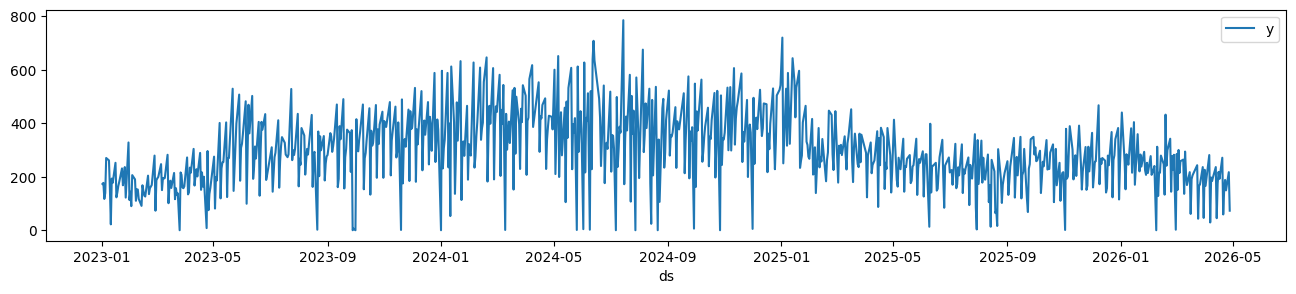

In [550]:
fig, ax = plt.subplots(figsize=(16, 3))
df_series = (
    series.to_pandas().set_index("ds")  #
)
sns.lineplot(df_series, ax=ax)

<Axes: xlabel='ds'>

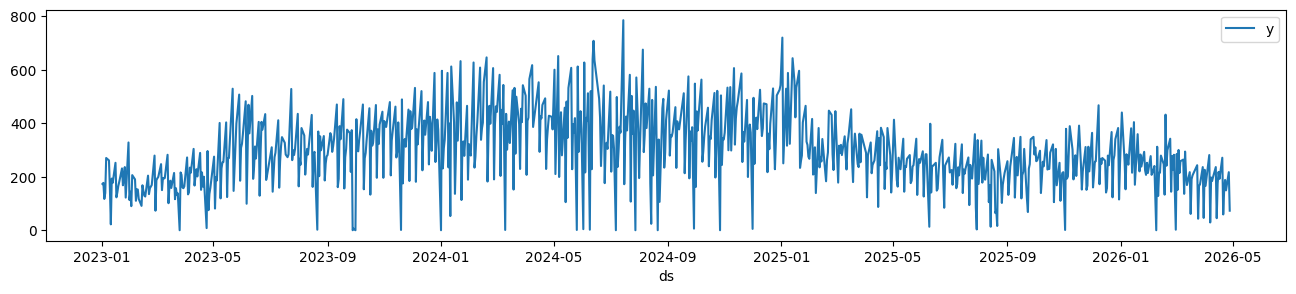

In [547]:
fig, ax = plt.subplots(figsize=(16, 3))
df_series = (
    series.to_pandas().set_index("ds")  #
)
sns.lineplot(df_series, ax=ax)

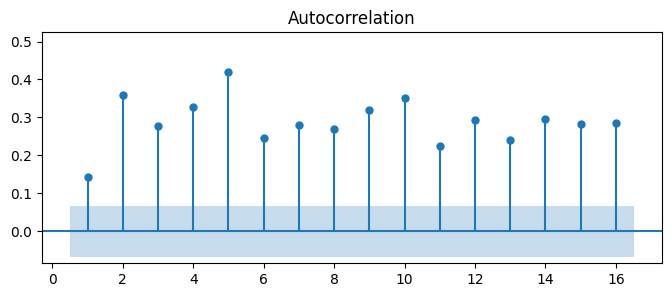

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(
    df_series["y"], lags=16, ax=ax, zero=False, bartlett_confint=False, auto_ylims=True
)
fig.show()

In [530]:
stl = STL(
    df_series["y"],
    period=7,
    seasonal=7,
    trend=9,
)
res = stl.fit()
dcmp = pd.DataFrame(
    {
        "ds": series["ds"],
        "data": series["y"],
        "trend": res.trend,
        "seasonal": res.seasonal,
        "remainder": res.resid,
    }
).reset_index(drop=True)

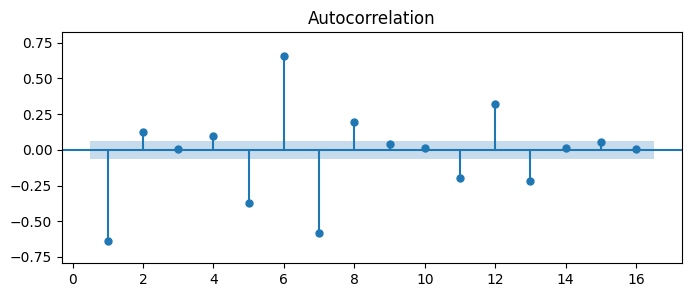

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(
    dcmp["remainder"],
    lags=16,
    ax=ax,
    zero=False,
    bartlett_confint=False,
    auto_ylims=True,
)
fig.show()

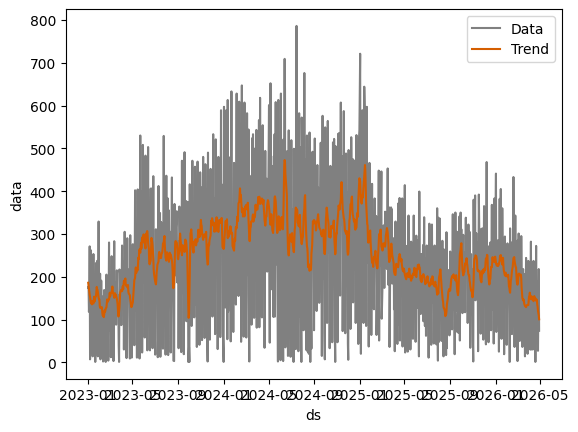

In [532]:
fig, ax = plt.subplots()
sns.lineplot(data=dcmp, x="ds", y="data", color="gray", label="Data")
sns.lineplot(data=dcmp, x="ds", y="trend", color="#D55E00", label="Trend")
plt.show()

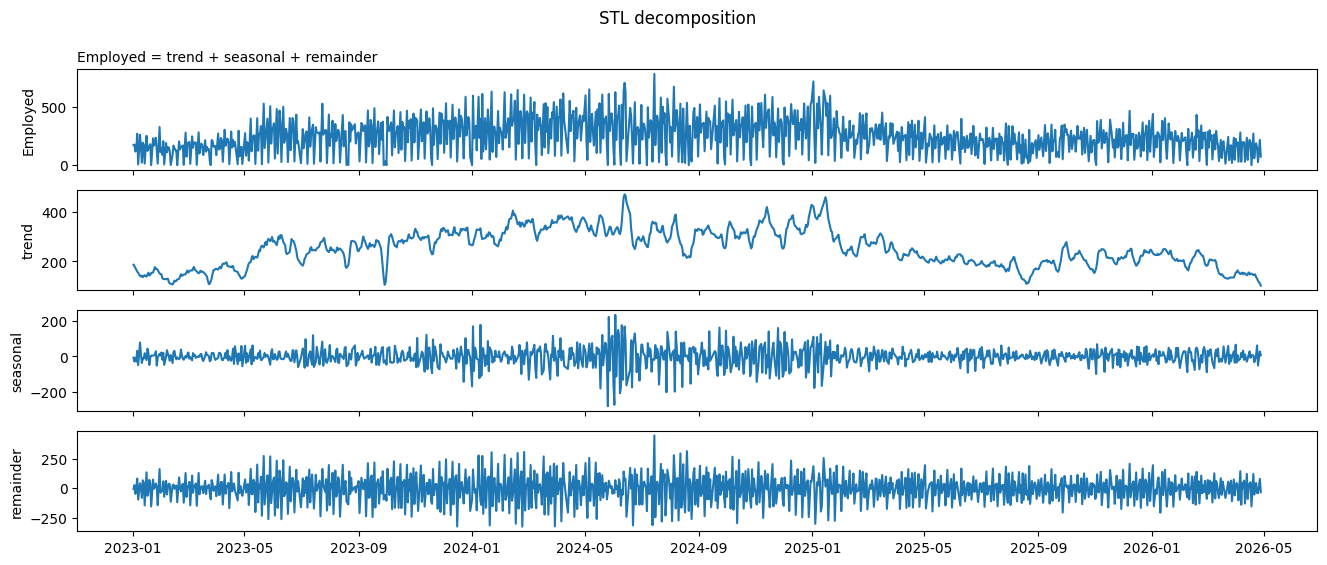

In [ ]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(16, 6))
sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3])
axes[0].set_title("Employed = trend + seasonal + remainder", size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

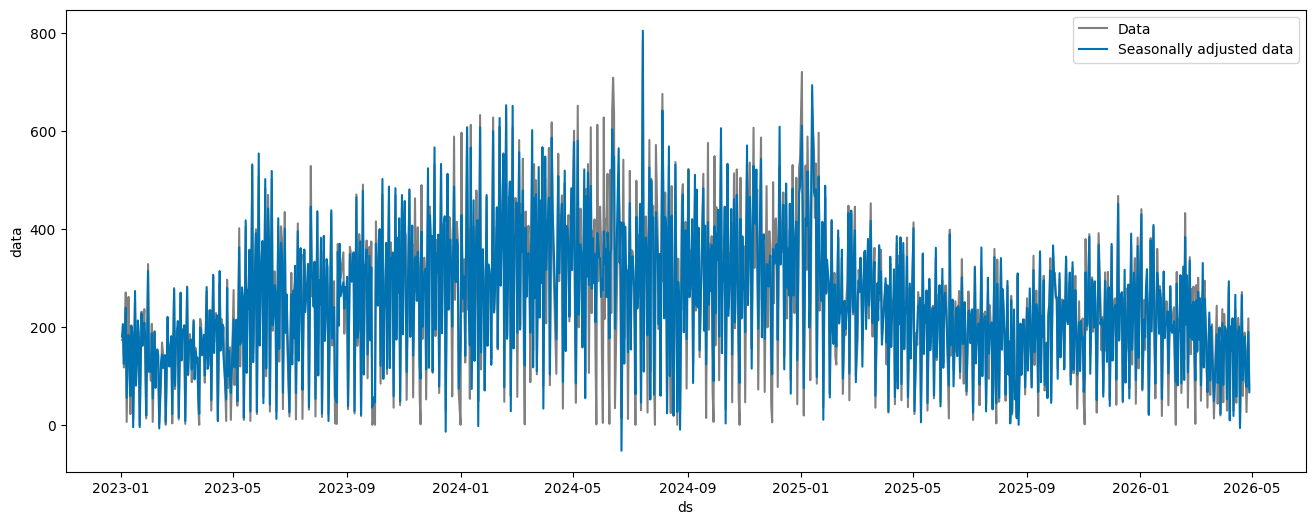

In [534]:
df = dcmp.assign(adj=lambda x: x["data"] - x["seasonal"])
fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(data=df, x="ds", y="data", color="gray", label="Data")
sns.lineplot(
    data=df, x="ds", y="adj", color="#0072B2", label="Seasonally adjusted data"
)
plt.show()

In [ ]:
summary_stats = tsf.tsfeatures(
    df_series, freq=6, features=[tsf.stl_features], scale=False
)

In [489]:
summary_stats

,unique_id,nperiods,seasonal_period,trend,spike,linearity,curvature,e_acf1,e_acf10,seasonal_strength,peak,trough
0,CENTRE COURRIER COLIS LAAYOUNE,1,6,0.356761,415.831934,-315.747976,-1765.448593,-0.508396,0.298519,0.422939,2,1


TypeError: DecomposeResult.plot() got an unexpected keyword argument 'ax'

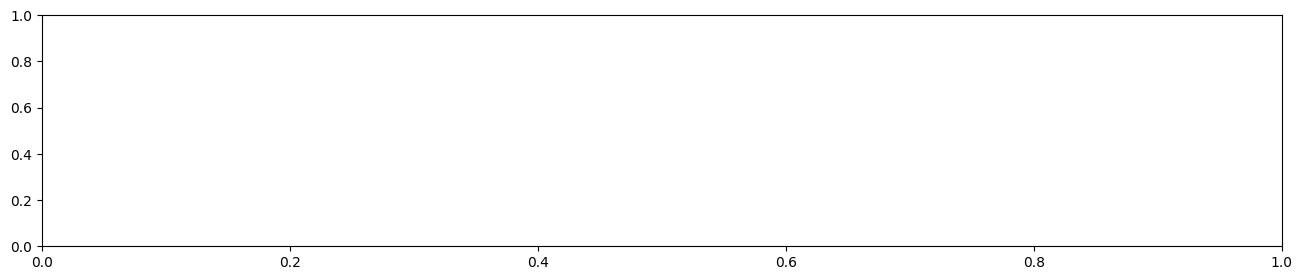

In [570]:
fig, ax = plt.subplots(figsize=(16, 3))
seasonal_decompose(series["y"], period=7).plot(ax=ax)
""

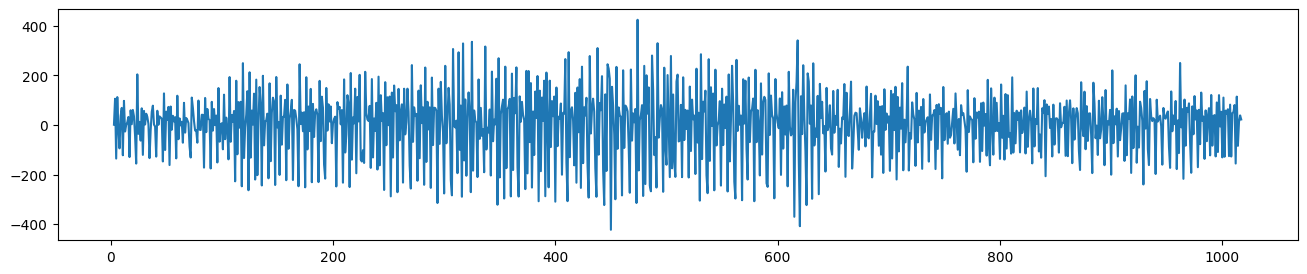

In [568]:
fig, ax = plt.subplots(figsize=(16, 3))
plt.plot(seasonal_decompose(series["y"], period=7).resid)

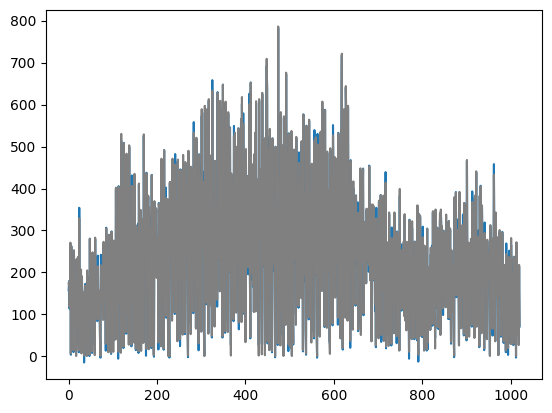

In [566]:
plt.plot(series["y"] - seasonal_decompose(series["y"], period=7).seasonal)
plt.plot(series["y"], color="gray")

In [ ]:
df = dcmp.assign(adj=lambda x: x["data"] - x["seasonal"])
fig, ax = plt.subplots()
sns.lineplot(data=df, x="ds", y="data", color="gray", label="Data")
sns.lineplot(
    data=df, x="ds", y="adj", color="#0072B2", label="Seasonally adjusted data"
)

AttributeError: 'DecomposeResult' object has no attribute 'assign'